# Posek – Time Series Analysis
**Target:** `kubikov` (m³ of wood harvested) aggregated monthly per `odsek` (forest section)

Sections:
1. Load & aggregate to monthly series
2. Aggregate (all odseki) trend & seasonality decomposition
3. ACF / PACF – lag analysis
4. Per-odsek exploration (top sections)
5. Build 12-month sliding-window dataset
6. Save processed datasets

In [24]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load & Monthly Aggregation

In [25]:
df_raw = pd.read_csv('../data/raw/ZGS/posek.csv', low_memory=False)

df = df_raw[['odsek', 'kubikov', 'posekano']].copy()
df = df.rename(columns={'posekano': 'datum'})
df['datum'] = pd.to_datetime(df['datum'])

# Monthly sum of kubikov per odsek, fill gaps with 0
df = df.set_index(['odsek', 'datum'])
monthly = (
    df.groupby('odsek')
      .resample('MS', level='datum')['kubikov']
      .sum()
      .rename('target')
      .reset_index()
)
monthly['leto_mesec'] = monthly['datum'].dt.to_period('M')
monthly['leto']  = monthly['datum'].dt.year
monthly['mesec'] = monthly['datum'].dt.month

# Pivot: rows = months, cols = odsek
pivot = monthly.pivot_table(index='datum', columns='odsek', values='target', aggfunc='sum').fillna(0)

# Aggregate across all odseki
agg = pivot.sum(axis=1).rename('target')
agg.index = pd.DatetimeIndex(agg.index, freq='MS')

print(f'Odseki: {pivot.shape[1]:,}   |   Months: {len(agg)}   |   Date range: {agg.index[0].date()} – {agg.index[-1].date()}')
monthly.head()

Odseki: 25,691   |   Months: 228   |   Date range: 2007-01-01 – 2025-12-01


,odsek,datum,target,leto_mesec,leto,mesec
0,01 1A,2007-07-01,140.5,2007-07,2007,7
1,01 1A,2007-08-01,0.0,2007-08,2007,8
2,01 1A,2007-09-01,0.0,2007-09,2007,9
3,01 1A,2007-10-01,0.0,2007-10,2007,10
4,01 1A,2007-11-01,0.0,2007-11,2007,11


## 2. Trend & Seasonality

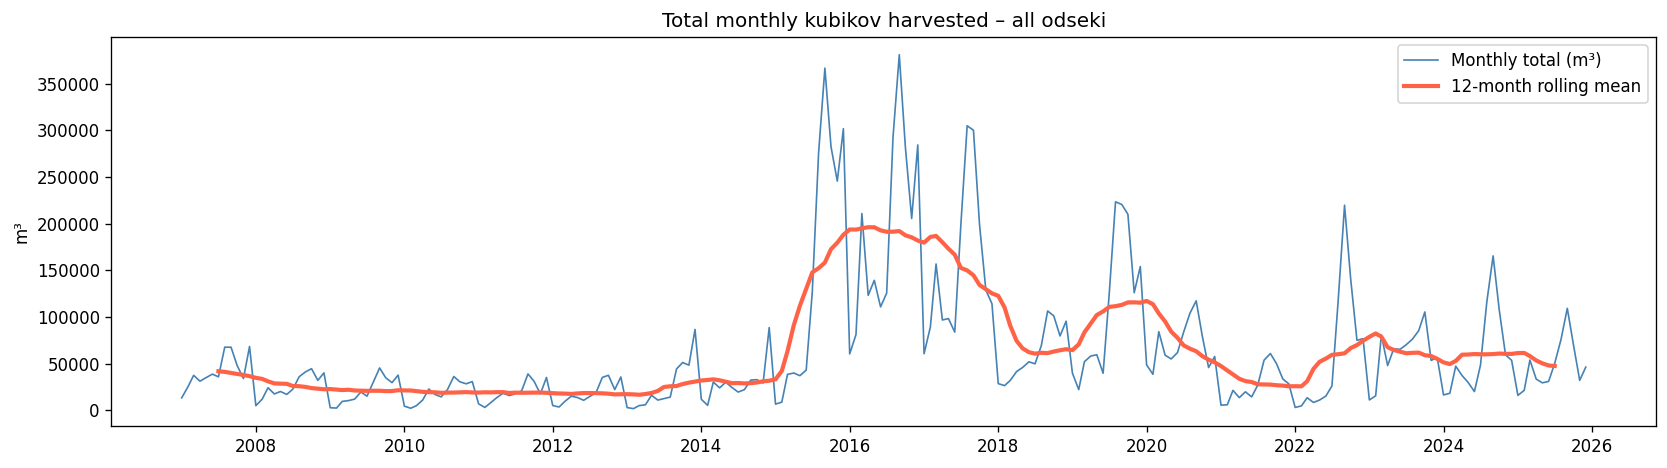

In [26]:
# --- Raw aggregate series ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(agg.index, agg.values, lw=1, color='steelblue', label='Monthly total (m³)')
ax.plot(agg.index, agg.rolling(12, center=True).mean(), lw=2.5, color='tomato', label='12-month rolling mean')
ax.set_title('Total monthly kubikov harvested – all odseki')
ax.set_ylabel('m³')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

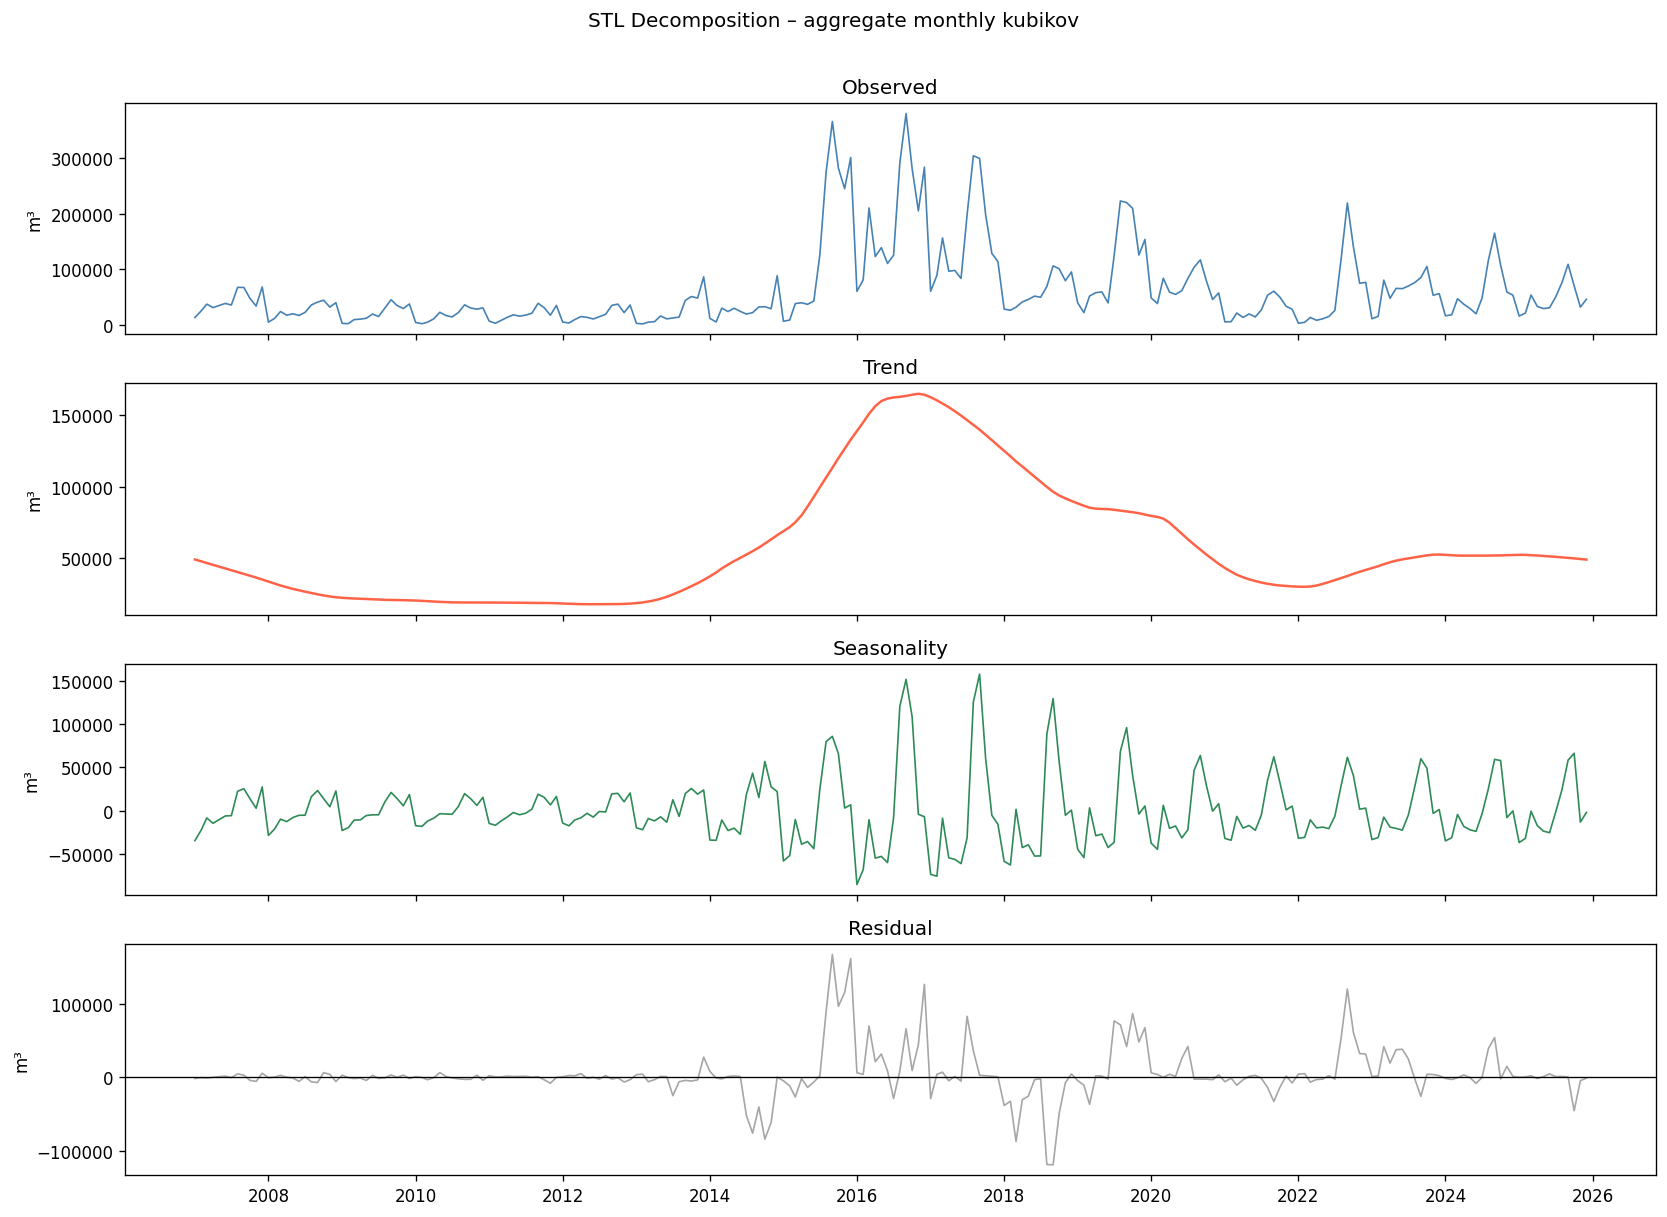

In [27]:
# --- STL decomposition (robust to outliers) ---
stl = STL(agg, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(agg, lw=1, color='steelblue'); axes[0].set_title('Observed')
axes[1].plot(stl.trend, lw=1.5, color='tomato'); axes[1].set_title('Trend')
axes[2].plot(stl.seasonal, lw=1, color='seagreen'); axes[2].set_title('Seasonality')
axes[3].plot(stl.resid, lw=1, color='gray', alpha=0.7); axes[3].axhline(0, color='k', lw=0.8)
axes[3].set_title('Residual')
for ax in axes:
    ax.set_ylabel('m³')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('STL Decomposition – aggregate monthly kubikov', y=1.01)
plt.tight_layout()
plt.show()

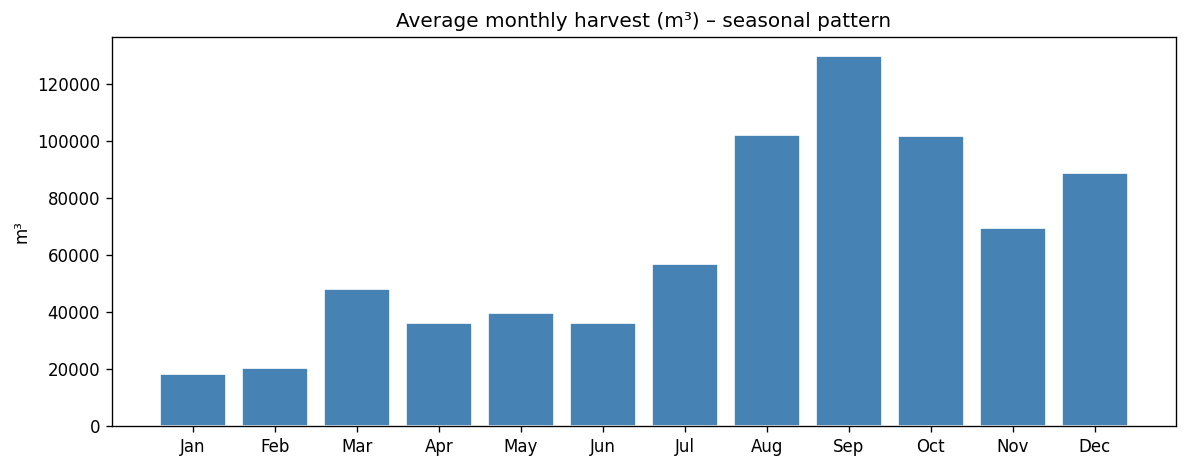

In [28]:
# --- Average seasonal pattern (month-of-year) ---
seasonal_df = pd.DataFrame({'target': agg.values, 'mesec': agg.index.month})
monthly_avg = seasonal_df.groupby('mesec')['target'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Average monthly harvest (m³) – seasonal pattern')
ax.set_ylabel('m³')
plt.tight_layout()
plt.show()

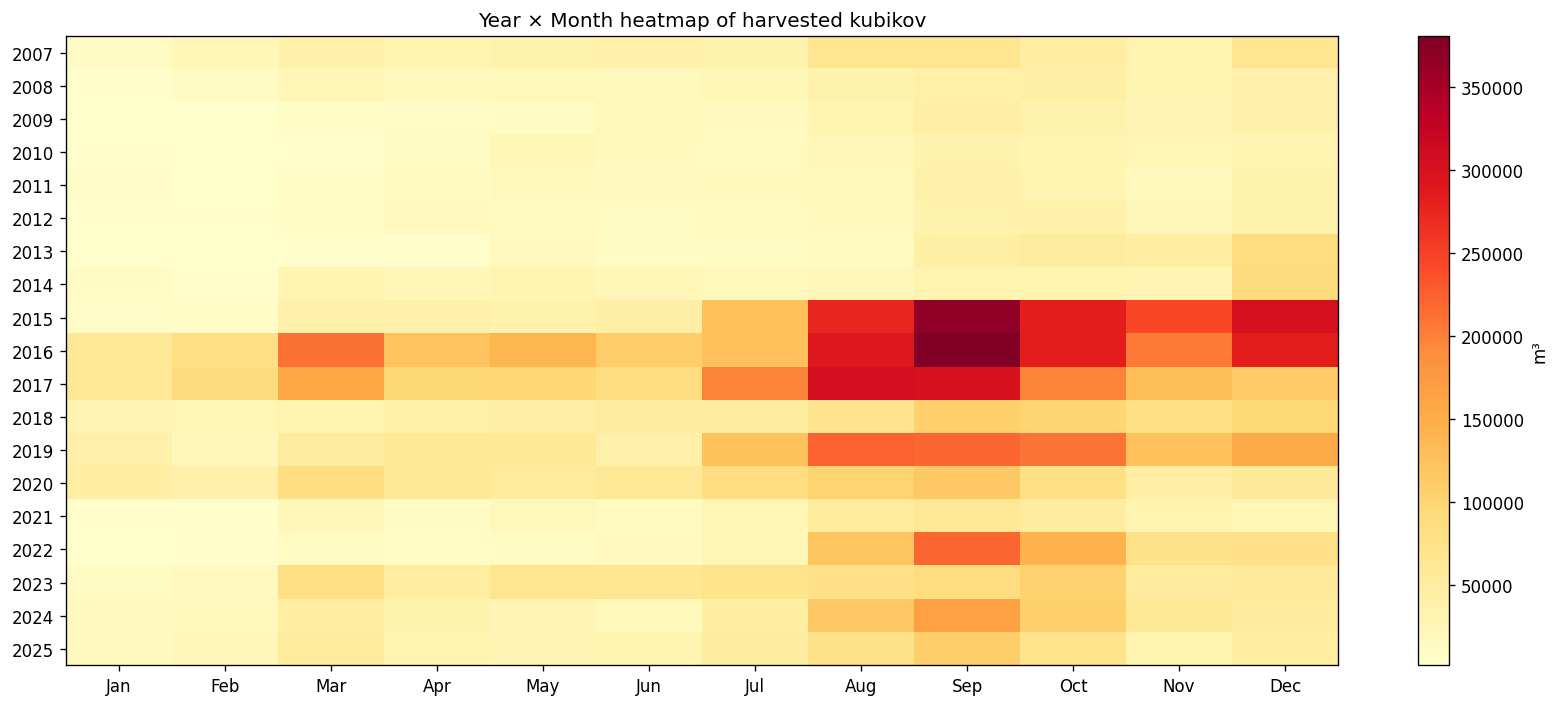

In [29]:
# --- Year-over-year comparison (heatmap) ---
yoy = seasonal_df.copy()
yoy['leto'] = agg.index.year
heat = yoy.groupby(['leto', 'mesec'])['target'].sum().unstack('mesec')

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Year × Month heatmap of harvested kubikov')
plt.colorbar(im, ax=ax, label='m³')
plt.tight_layout()
plt.show()

In [30]:
# Copy original series so you don't overwrite it
series = agg.dropna().copy()

max_diffs = 5        # safety limit
num_diffs = 0        # how many times differenced

print("=== Augmented Dickey-Fuller Test with Auto-Differencing ===")

while num_diffs <= max_diffs:

    adf_result = adfuller(series, autolag='AIC')

    adf_stat = adf_result[0]
    p_value = adf_result[1]
    critical_vals = {k: round(v, 3) for k, v in adf_result[4].items()}

    print(f"\n--- Test after {num_diffs} difference(s) ---")
    print(f"ADF statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")
    print(f"Critical values: {critical_vals}")

    # Check stationarity
    if p_value < 0.05:
        print("=> Series is STATIONARY")
        break

    # Stop if reached max
    if num_diffs == max_diffs:
        print("=> Reached maximum differencing limit.")
        print("=> Series may still be NON-STATIONARY.")
        break

    # Apply differencing
    series = series.diff().dropna()
    num_diffs += 1

print(f"\nTotal differences applied: {num_diffs}")

# Save results
stationary_series = series
d_value = num_diffs

=== Augmented Dickey-Fuller Test with Auto-Differencing ===

--- Test after 0 difference(s) ---
ADF statistic : -2.2876
p-value       : 0.1760
Critical values: {'1%': np.float64(-3.461), '5%': np.float64(-2.875), '10%': np.float64(-2.574)}

--- Test after 1 difference(s) ---
ADF statistic : -4.5686
p-value       : 0.0001
Critical values: {'1%': np.float64(-3.461), '5%': np.float64(-2.875), '10%': np.float64(-2.574)}
=> Series is STATIONARY

Total differences applied: 1


## 3. Lag Analysis – ACF & PACF

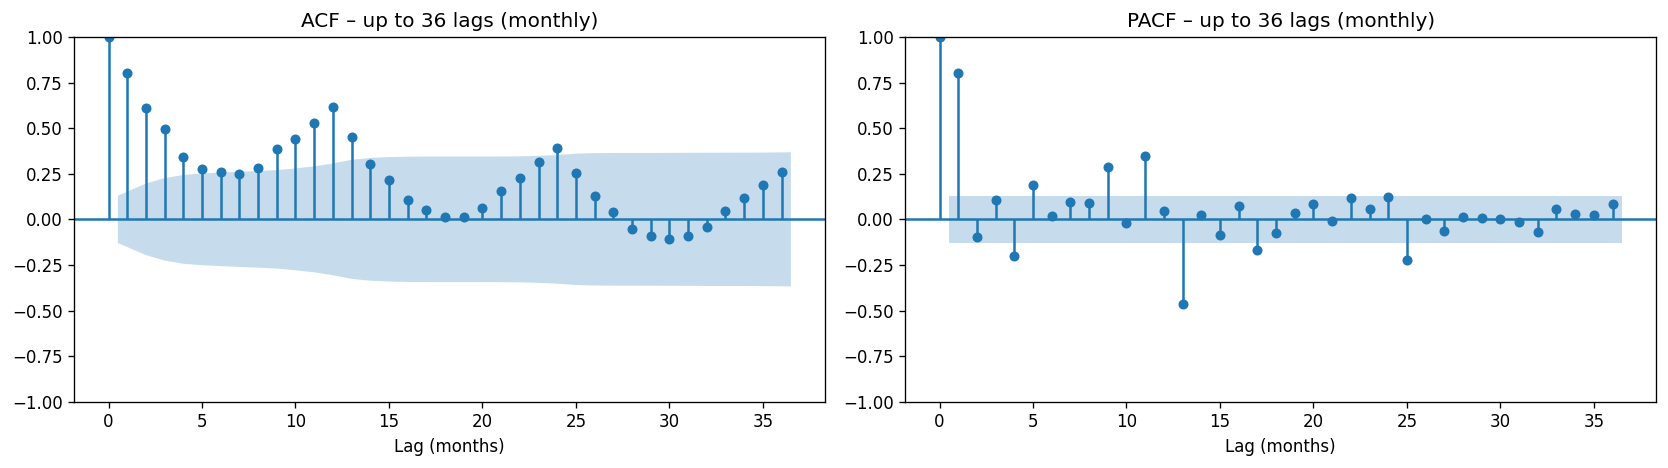

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(agg.dropna(),  lags=36, ax=axes[0], title='ACF – up to 36 lags (monthly)')
plot_pacf(agg.dropna(), lags=36, ax=axes[1], title='PACF – up to 36 lags (monthly)', method='ywm')
for ax in axes:
    ax.set_xlabel('Lag (months)')
plt.tight_layout()
plt.show()

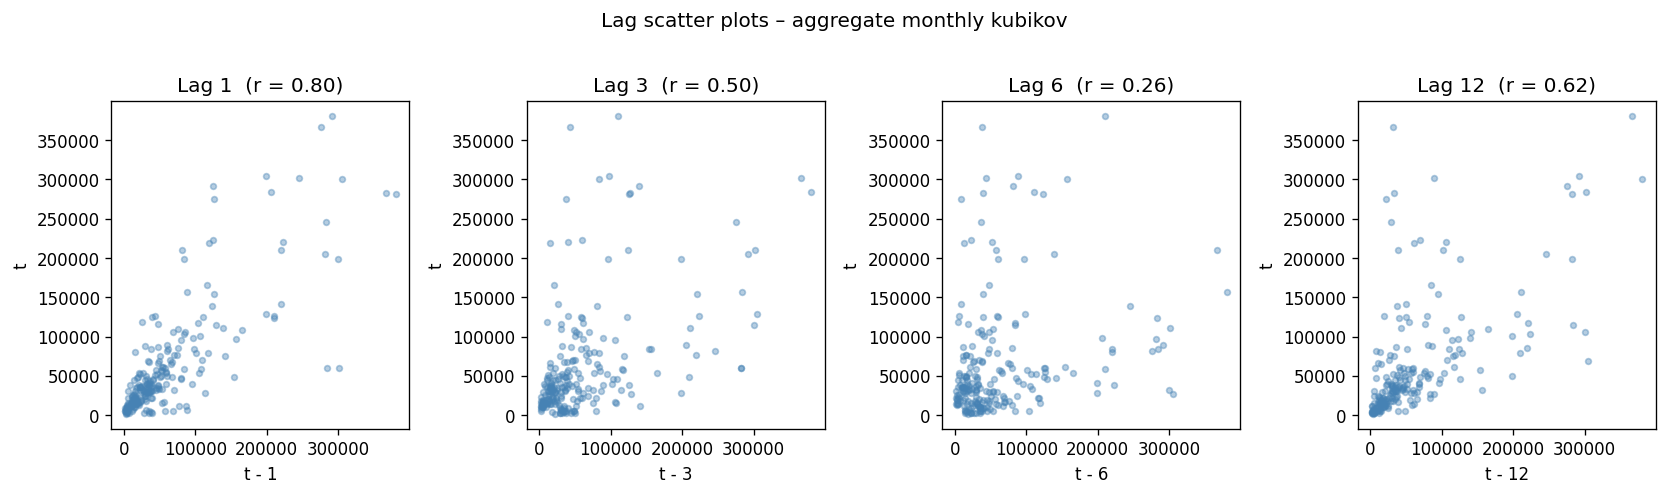

In [32]:
# --- Manual lag scatter plots for lags 1, 3, 6, 12 ---
lags_to_plot = [1, 3, 6, 12]
fig, axes = plt.subplots(1, len(lags_to_plot), figsize=(14, 4))
for ax, lag in zip(axes, lags_to_plot):
    shifted = agg.shift(lag)
    mask = shifted.notna() & agg.notna()
    corr = agg[mask].corr(shifted[mask])
    ax.scatter(shifted[mask], agg[mask], alpha=0.4, s=12, color='steelblue')
    ax.set_title(f'Lag {lag}  (r = {corr:.2f})')
    ax.set_xlabel(f't - {lag}')
    ax.set_ylabel('t')
plt.suptitle('Lag scatter plots – aggregate monthly kubikov', y=1.02)
plt.tight_layout()
plt.show()

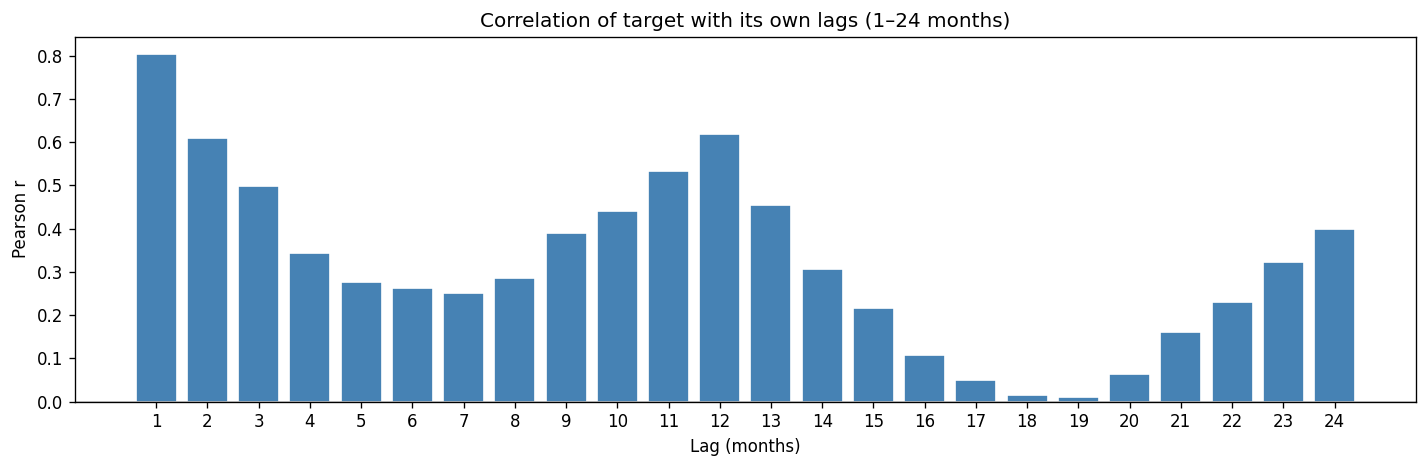

In [33]:
# --- Lag correlation bar chart (lags 1-24) ---
lag_corrs = [agg.corr(agg.shift(l)) for l in range(1, 25)]
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in lag_corrs]
ax.bar(range(1, 25), lag_corrs, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Lag (months)'); ax.set_ylabel('Pearson r')
ax.set_title('Correlation of target with its own lags (1–24 months)')
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

## 4. Per-Odsek Exploration (Top Sections)

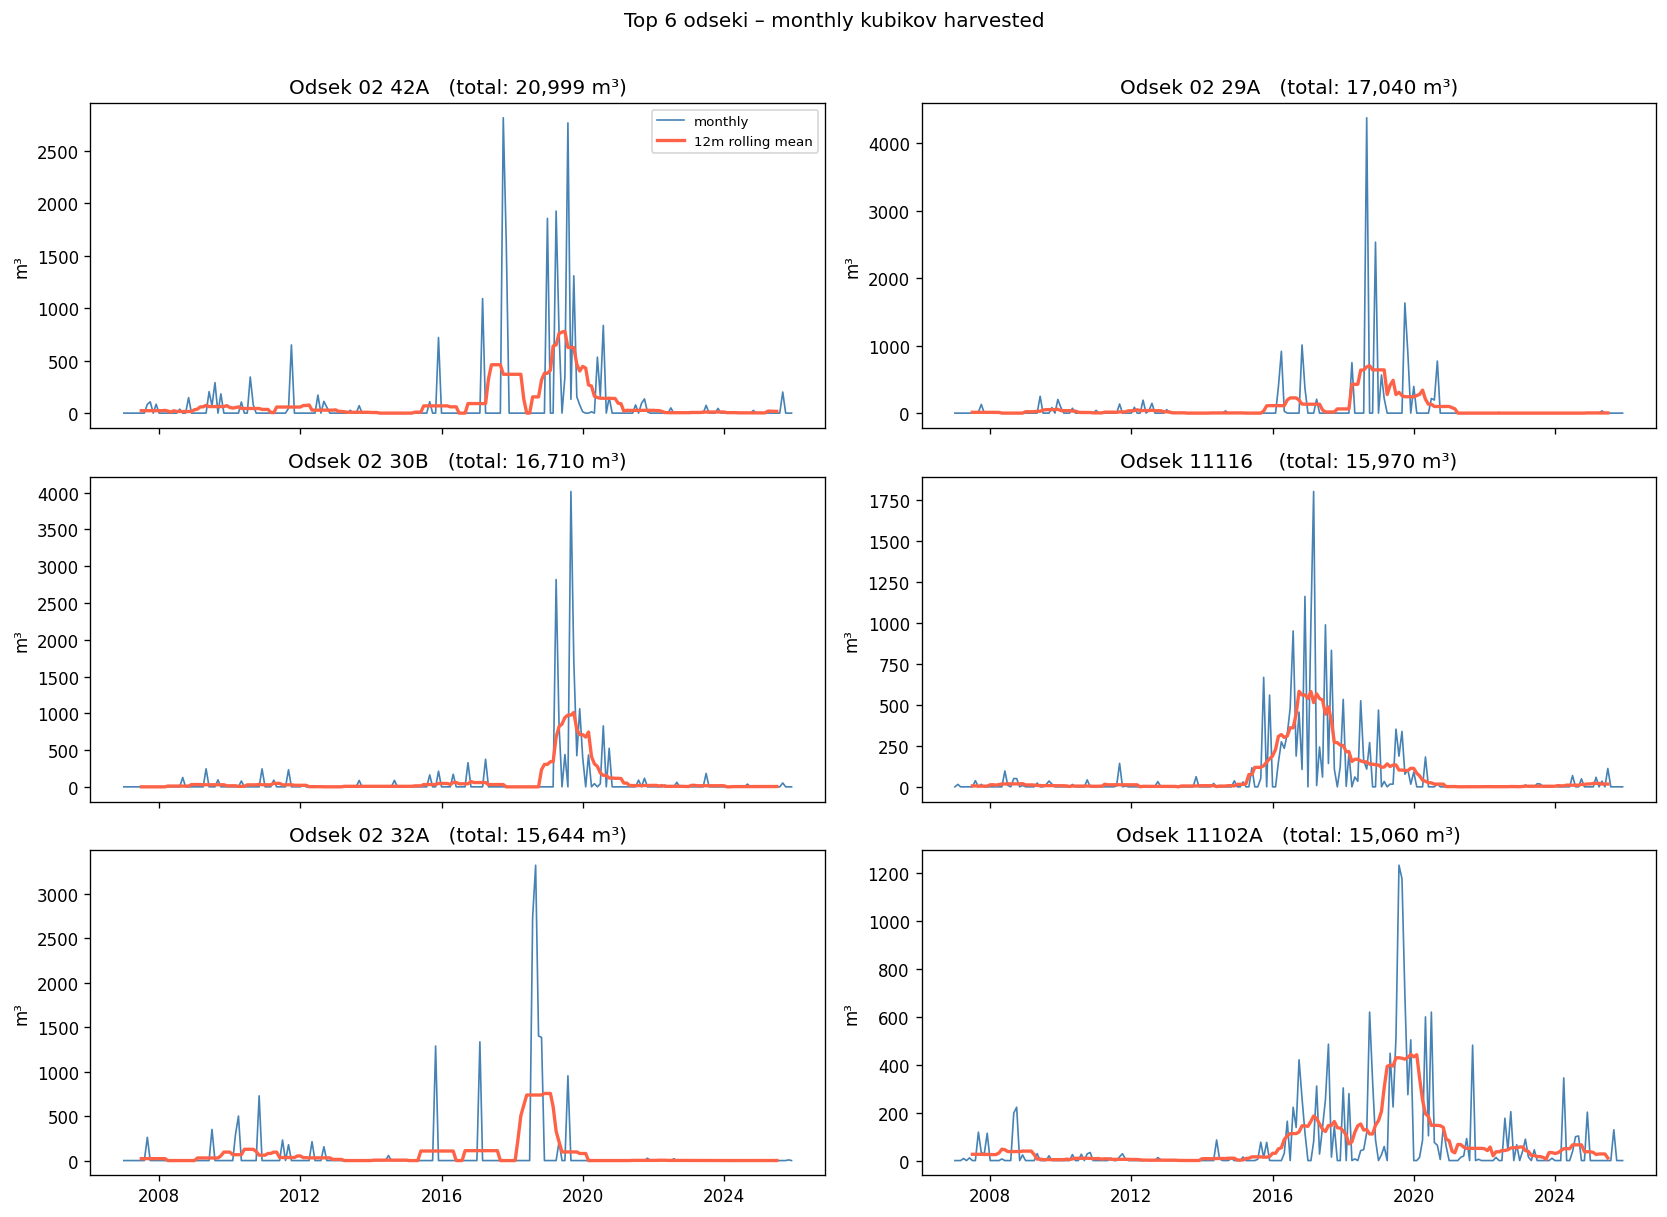

In [34]:
# Top 6 odseki by total harvest
top_odseki = pivot.sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for ax, odsek in zip(axes.flat, top_odseki):
    s = pivot[odsek]
    ax.plot(s.index, s.values, lw=1, color='steelblue', label='monthly')
    ax.plot(s.index, s.rolling(12, center=True).mean(), lw=2, color='tomato', label='12m rolling mean')
    ax.set_title(f'Odsek {odsek}  (total: {s.sum():,.0f} m³)')
    ax.set_ylabel('m³')
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes.flat[0].legend(fontsize=8)
plt.suptitle('Top 6 odseki – monthly kubikov harvested', y=1.01)
plt.tight_layout()
plt.show()

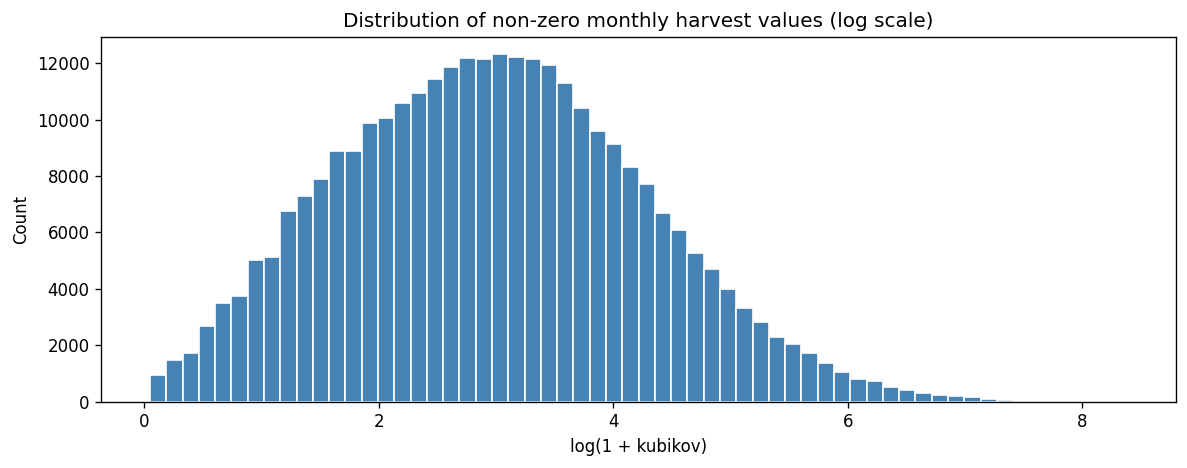

In [35]:
# Distribution of non-zero monthly harvest values per odsek (log scale)
non_zero = monthly[monthly['target'] > 0]['target']
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(non_zero), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel('log(1 + kubikov)')
ax.set_ylabel('Count')
ax.set_title('Distribution of non-zero monthly harvest values (log scale)')
plt.tight_layout()
plt.show()